# Non-cheatable ICL: input repetition task

The task: `input → inputinput` (concatenate the input with itself).

**Why this is non-cheatable in the right sense.** Each demo output is unique to its input (outputs don't share vocabulary structure). The answer for any query is a deterministic function of the specific query input. There is no output-vocabulary shortcut: seeing a random nonsense repetition doesn't cue the model to produce any specific next token. Query-only accuracy should be near zero because the rule-of-this-prompt (repeat) must be inferred from demos.

**Why 3B should be capable of it.** The task reduces to induction-head copying: find the input, copy it, copy it again. This is within known capabilities at this scale.

**Multi-token evaluation.** The repeated output is typically 2-3 tokens. We score correctness by generating enough tokens to cover the expected output and checking a prefix match of the decoded string.

In [1]:
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, random, seaborn as sns
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from math import sqrt
from transformer_lens import HookedTransformer
from configs import *
from utils import *
%matplotlib inline

sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
rng = random.Random(42)

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-25 10:07:22.908005: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.14it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


## Multi-token correctness check

Generate up to `max_new_tokens` greedy continuations from the prompt. Decode to a string and strip whitespace. Return True if the decoded continuation starts with the expected output (case-insensitive prefix match).

In [2]:
@torch.no_grad()
def check_correct_multitoken(model, tokens, expected_output, max_new_tokens=6):
    """Greedy-decode up to max_new_tokens starting from `tokens`, check if the decoded continuation prefix-matches expected_output."""
    generated = []
    cur_tokens = tokens.clone()
    for _ in range(max_new_tokens):
        logits = model(cur_tokens)[0, -1]
        next_tok = logits.argmax().item()
        generated.append(next_tok)
        cur_tokens = torch.cat([cur_tokens, torch.tensor([[next_tok]], device=cur_tokens.device)], dim=1)
    decoded = model.tokenizer.decode(generated).strip().lower()
    target = expected_output.strip().lower()
    return decoded.startswith(target), decoded

## Build nonsense-word vocabulary and prompts

In [3]:
CONSONANTS = 'bdfghjklmnprstvwz'
VOWELS = 'aeiou'

def make_nonsense(length=5):
    pattern = [CONSONANTS, VOWELS] * (length // 2 + 1)
    return ''.join(rng.choice(p) for p in pattern[:length])

def repeat_rule(s):
    return s + s

RULE = repeat_rule
RULE_NAME = 'repeat'

def generate_pool(target_count=500, max_attempts=5000):
    seen = set()
    out = []
    attempts = 0
    while len(out) < target_count and attempts < max_attempts:
        w = make_nonsense(5)
        if w in seen:
            attempts += 1
            continue
        seen.add(w)
        out.append(w)
        attempts += 1
    return out

pool = generate_pool(500)
print(f'Generated {len(pool)} nonsense words. Examples: {pool[:10]}')
print(f'Rule ({RULE_NAME}) applied: {[(w, RULE(w)) for w in pool[:5]]}')

N_PROMPTS = 50
N_DEMOS = 10

prompts_data = []
used = set()
for p_idx in range(N_PROMPTS):
    available = [w for w in pool if w not in used]
    if len(available) < 11:
        used = set()
        available = pool[:]
    chosen = rng.sample(available, 11)
    for w in chosen:
        used.add(w)
    demo_inputs = chosen[:10]
    demo_outputs = [RULE(w) for w in demo_inputs]
    query_input = chosen[10]
    query_output = RULE(query_input)
    
    prompts_data.append({
        'demo_pairs': list(zip(demo_inputs, demo_outputs)),
        'query_input': query_input,
        'query_output': query_output,
        'prompt': build_icl_prompt(list(zip(demo_inputs, demo_outputs)), query_input),
    })

print(f'\nBuilt {len(prompts_data)} prompts.')
print(f'Example prompt:\n{prompts_data[0]["prompt"]}')
print(f'Expected answer: {prompts_data[0]["query_output"]}')

Generated 500 nonsense words. Examples: ['gamel', 'hafut', 'dafel', 'zubuk', 'tevum', 'betim', 'hepaf', 'sarim', 'dogof', 'nuruk']
Rule (repeat) applied: [('gamel', 'gamelgamel'), ('hafut', 'hafuthafut'), ('dafel', 'dafeldafel'), ('zubuk', 'zubukzubuk'), ('tevum', 'tevumtevum')]

Built 50 prompts.
Example prompt:
jazaj → jazajjazaj
jotub → jotubjotub
vefog → vefogvefog
hagol → hagolhagol
marev → marevmarev
repaj → repajrepaj
jiris → jirisjiris
lovuz → lovuzlovuz
pabot → pabotpabot
huruz → huruzhuruz
majul →
Expected answer: majulmajul


## Sanity check: does Llama 3.2 3B do this task in orig condition?

In [4]:
correct_orig = []
examples = []
for pdata in tqdm(prompts_data):
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    ok, got = check_correct_multitoken(model, tokens, pdata['query_output'], max_new_tokens=6)
    correct_orig.append(int(ok))
    examples.append((pdata['query_input'], pdata['query_output'], got, ok))
    torch.cuda.empty_cache()

orig_acc = np.mean(correct_orig)
print(f'\nOrig accuracy on {RULE_NAME} task: {orig_acc:.3f} ({sum(correct_orig)}/{len(correct_orig)})')
print('\nExamples:')
for qi, qo, got, ok in examples[:15]:
    mark = '✓' if ok else '✗'
    print(f'  {mark} query={qi:<8} expected={qo:<12} got={got!r}')

100%|██████████| 50/50 [00:12<00:00,  3.97it/s]


Orig accuracy on repeat task: 0.960 (48/50)

Examples:
  ✓ query=majul    expected=majulmajul   got='majulmajul\nj'
  ✓ query=hepaf    expected=hepafhepaf   got='hepafhepaf'
  ✓ query=wobab    expected=wobabwobab   got='wobabwobab'
  ✓ query=wufot    expected=wufotwufot   got='wufotwufot'
  ✓ query=towen    expected=towentowen   got='towentowen\nm'
  ✓ query=tawof    expected=tawoftawof   got='tawoftawof'
  ✓ query=lewid    expected=lewidlewid   got='lewidlewid\nk'
  ✓ query=wemow    expected=wemowwemow   got='wemowwemow'
  ✓ query=nitek    expected=niteknitek   got='niteknitek'
  ✗ query=tisos    expected=tisostisos   got='tisositos\nzih'
  ✓ query=rufiv    expected=rufivrufiv   got='rufivrufiv'
  ✓ query=pokeh    expected=pokehpokeh   got='pokehpokeh\nz'
  ✓ query=vonoz    expected=vonozvonoz   got='vonozvonoz\nz'
  ✓ query=zafab    expected=zafabzafab   got='zafabzafab'
  ✓ query=bepol    expected=bepolbepol   got='bepolbepol'


## Also check the query-only baseline

Make sure that without demos, the model cannot produce the repeated output. If query_only accuracy is non-trivial, the task is cheatable via prompt-format cueing alone.

In [5]:
correct_qo = []
examples_qo = []
for pdata in tqdm(prompts_data):
    zs_prompt = f'{pdata["query_input"]} \u2192'
    tokens = model.to_tokens(zs_prompt, prepend_bos=True)
    ok, got = check_correct_multitoken(model, tokens, pdata['query_output'], max_new_tokens=6)
    correct_qo.append(int(ok))
    examples_qo.append((pdata['query_input'], pdata['query_output'], got, ok))
    torch.cuda.empty_cache()

qo_acc = np.mean(correct_qo)
print(f'\nQuery-only accuracy on {RULE_NAME} task: {qo_acc:.3f} ({sum(correct_qo)}/{len(correct_qo)})')
print('\nExamples:')
for qi, qo, got, ok in examples_qo[:10]:
    mark = '✓' if ok else '✗'
    print(f'  {mark} query={qi:<8} expected={qo:<12} got={got!r}')

100%|██████████| 50/50 [00:12<00:00,  4.10it/s]


Query-only accuracy on repeat task: 0.000 (0/50)

Examples:
  ✗ query=majul    expected=majulmajul   got='the buddha’s teaching on'
  ✗ query=hepaf    expected=hepafhepaf   got='the hepatitis c virus'
  ✗ query=wobab    expected=wobabwobab   got='the word “wob'
  ✗ query=wufot    expected=wufotwufot   got='the buddha’s teachings'
  ✗ query=towen    expected=towentowen   got='the 2012-'
  ✗ query=tawof    expected=tawoftawof   got='the taw of the'
  ✗ query=lewid    expected=lewidlewid   got='the 2018-'
  ✗ query=wemow    expected=wemowwemow   got='the wemow lake'
  ✗ query=nitek    expected=niteknitek   got='the nitek'
  ✗ query=tisos    expected=tisostisos   got='the 2018-'


## Build input and output pools

In [6]:
W_E = model.W_E.detach()

input_pool_all = []
input_tokids = []
output_pool_all = []
output_tokids = []
for pdata in prompts_data:
    for i, o in pdata['demo_pairs']:
        input_pool_all.append(i)
        input_tokids.append(model.to_tokens(' ' + i, prepend_bos=False)[0, 0].item())
        output_pool_all.append(o)
        output_tokids.append(model.to_tokens(' ' + o, prepend_bos=False)[0, 0].item())

mean_input_embed  = W_E[input_tokids].mean(dim=0)
mean_output_embed = W_E[output_tokids].mean(dim=0)

print(f'Input pool size: {len(input_pool_all)}')
print(f'Output pool size: {len(output_pool_all)}')

Input pool size: 500
Output pool size: 500


## Run input and output manipulations

All manipulations scored with multi-token generation (`max_new_tokens=6`) and prefix matching of the decoded continuation. Takes ~5-10 minutes because each prompt runs through 10 conditions and each condition generates 6 tokens.

In [7]:
def make_embed_hook(positions, replacement_vec):
    def hook_fn(emb, hook):
        for p in positions:
            emb[:, p, :] = replacement_vec.to(emb.dtype)
        return emb
    return hook_fn

@torch.no_grad()
def check_correct_with_hooks(model, tokens, expected_output, hooks=None, max_new_tokens=6):
    generated = []
    cur_tokens = tokens.clone()
    for _ in range(max_new_tokens):
        if hooks:
            logits = model.run_with_hooks(cur_tokens, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur_tokens)[0, -1]
        next_tok = logits.argmax().item()
        generated.append(next_tok)
        cur_tokens = torch.cat([cur_tokens, torch.tensor([[next_tok]], device=cur_tokens.device)], dim=1)
    decoded = model.tokenizer.decode(generated).strip().lower()
    target = expected_output.strip().lower()
    return int(decoded.startswith(target))

@torch.no_grad()
def target_logprob_with_hooks(model, tokens, expected_output, hooks=None):
    """Teacher-forced sum log p(target_i | target_<i) starting from `tokens`.
    Hooks (if provided) apply to every forward step."""
    target_ids = model.to_tokens(' ' + expected_output.strip(), prepend_bos=False)[0].tolist()
    
    total_logprob = 0.0
    cur_tokens = tokens.clone()
    for target_tok in target_ids:
        if hooks:
            logits = model.run_with_hooks(cur_tokens, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur_tokens)[0, -1]
        log_probs = torch.log_softmax(logits.float(), dim=-1)
        total_logprob += log_probs[target_tok].item()
        cur_tokens = torch.cat([cur_tokens, torch.tensor([[target_tok]], device=cur_tokens.device)], dim=1)
    
    return total_logprob

CONDS = [
    'orig',
    'shuffled_inputs', 'random_inputs', 'mean_embed_inputs', 'star_inputs',
    'shuffled_outputs', 'random_outputs', 'mean_embed_outputs', 'star_outputs',
    'query_only',
]
correct = {c: [] for c in CONDS}
logp    = {c: [] for c in CONDS}

for pdata in tqdm(prompts_data):
    demos = pdata['demo_pairs']
    qi = pdata['query_input']
    ans = pdata['query_output']
    
    inputs  = [i for i, _ in demos]
    outputs = [o for _, o in demos]
    
    inputs_shuffled  = inputs.copy();  rng.shuffle(inputs_shuffled)
    outputs_shuffled = outputs.copy(); rng.shuffle(outputs_shuffled)
    inputs_random    = [rng.choice(input_pool_all)  for _ in inputs]
    outputs_random   = [rng.choice(output_pool_all) for _ in outputs]
    
    prompts = {
        'orig':             pdata['prompt'],
        'shuffled_inputs':  build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
        'random_inputs':    build_icl_prompt(list(zip(inputs_random, outputs)), qi),
        'star_inputs':      build_icl_prompt([('*', o) for o in outputs], qi),
        'shuffled_outputs': build_icl_prompt(list(zip(inputs, outputs_shuffled)), qi),
        'random_outputs':   build_icl_prompt(list(zip(inputs, outputs_random)), qi),
        'star_outputs':     build_icl_prompt([(i, '*') for i in inputs], qi),
        'query_only':       f'{qi} \u2192',
    }
    tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
    
    for k in prompts:
        correct[k].append(check_correct_with_hooks(model, tokens[k], ans))
        logp[k].append(target_logprob_with_hooks(model, tokens[k], ans))
    
    per_demo_orig = find_per_demo_positions(model, prompts['orig'], demos)
    input_positions  = [p for d in per_demo_orig for p in d.get('input_positions', [])]
    output_positions = [p for d in per_demo_orig for p in d.get('output_positions', [])]
    
    hook = [('hook_embed', make_embed_hook(input_positions, mean_input_embed))]
    correct['mean_embed_inputs'].append(check_correct_with_hooks(model, tokens['orig'], ans, hooks=hook))
    logp['mean_embed_inputs'].append(target_logprob_with_hooks(model, tokens['orig'], ans, hooks=hook))
    
    hook = [('hook_embed', make_embed_hook(output_positions, mean_output_embed))]
    correct['mean_embed_outputs'].append(check_correct_with_hooks(model, tokens['orig'], ans, hooks=hook))
    logp['mean_embed_outputs'].append(target_logprob_with_hooks(model, tokens['orig'], ans, hooks=hook))
    
    torch.cuda.empty_cache()

for c in CONDS:
    correct[c] = np.array(correct[c])
    logp[c]    = np.array(logp[c])
total_n = len(correct['orig'])
print(f'\nTotal prompts: {total_n}')

100%|██████████| 50/50 [05:50<00:00,  7.01s/it]


Total prompts: 50


## Aggregate plot

/tmp/ipykernel_2452407/3458429989.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_long, x='Condition', y='Correct', order=order_labels,


Condition                   Mean            [95% CI]
----------------------------------------------------
orig                       0.960  [0.865, 0.989]
shuffled_inputs            0.480  [0.348, 0.615]
random_inputs              0.000  [0.000, 0.071]
mean_embed_inputs          0.000  [0.000, 0.071]
star_inputs                0.000  [0.000, 0.071]
shuffled_outputs           0.380  [0.259, 0.518]
random_outputs             0.040  [0.011, 0.135]
mean_embed_outputs         0.000  [0.000, 0.071]
star_outputs               0.000  [0.000, 0.071]
query_only                 0.000  [0.000, 0.071]


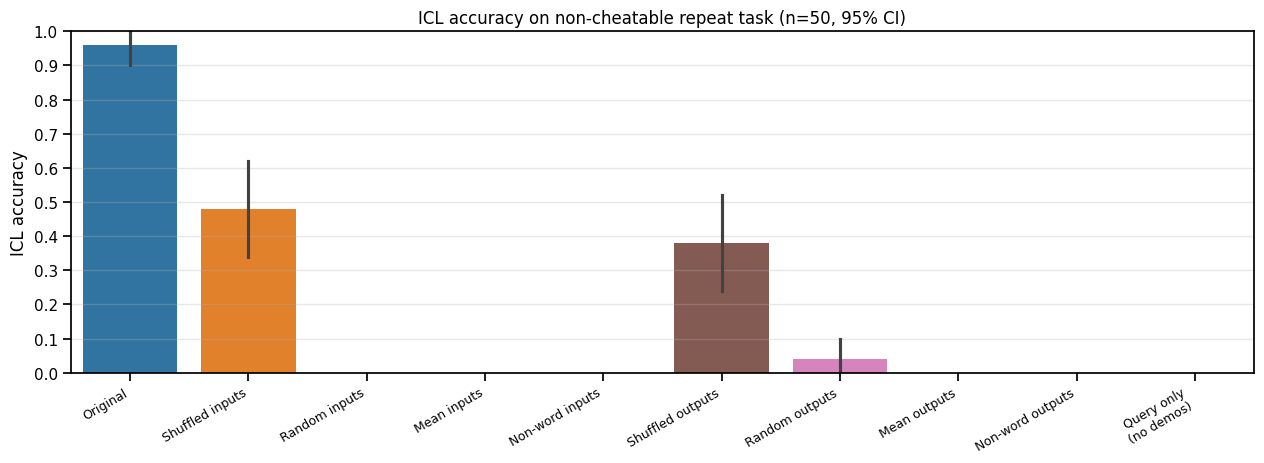

In [8]:
def wilson(k, n, Z=1.96):
    if n == 0: return 0, 0, 0
    p = k / n
    denom = 1 + Z**2/n
    c = (p + Z**2/(2*n)) / denom
    h = Z * sqrt(p*(1-p)/n + Z**2/(4*n**2)) / denom
    return p, max(0, c-h), min(1, c+h)

print(f'{"Condition":<24} {"Mean":>7}  {"[95% CI]":>18}')
print('-' * 52)
for c in CONDS:
    p, lo, hi = wilson(correct[c].sum(), total_n)
    print(f'{c:<24} {p:>7.3f}  [{lo:.3f}, {hi:.3f}]')

tick_map = {
    'orig':              'Original',
    'shuffled_inputs':   'Shuffled inputs',
    'random_inputs':     'Random inputs',
    'mean_embed_inputs': 'Mean inputs',
    'star_inputs':       'Non-word inputs',
    'shuffled_outputs':  'Shuffled outputs',
    'random_outputs':    'Random outputs',
    'mean_embed_outputs':'Mean outputs',
    'star_outputs':      'Non-word outputs',
    'query_only':        'Query only\n(no demos)',
}
order_keys = CONDS
order_labels = [tick_map[k] for k in order_keys]

df_long = pd.DataFrame({
    'Condition': np.concatenate([[tick_map[c]] * total_n for c in order_keys]),
    'Correct':   np.concatenate([correct[c] for c in order_keys]),
})

fig, ax = plt.subplots(figsize=(6.4*2, 4.8))
sns.barplot(data=df_long, x='Condition', y='Correct', order=order_labels,
            palette='tab10', errorbar=('ci', 95), linewidth=0, ax=ax)
ax.set_ylabel('ICL accuracy')
ax.set_xlabel('')
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.set_title(f'ICL accuracy on non-cheatable {RULE_NAME} task (n={total_n}, 95% CI)')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

Condition                 Mean logp                [95% CI]
------------------------------------------------------------
orig                         -0.560  [  -0.798,   -0.323]
shuffled_inputs              -3.681  [  -4.241,   -3.120]
random_inputs                -8.577  [  -9.209,   -7.945]
mean_embed_inputs            -8.137  [  -8.611,   -7.662]
star_inputs                  -7.626  [  -7.986,   -7.266]
shuffled_outputs             -4.314  [  -4.880,   -3.747]
random_outputs               -8.581  [  -9.149,   -8.013]
mean_embed_outputs          -20.945  [ -21.981,  -19.908]
star_outputs                -23.807  [ -24.572,  -23.042]
query_only                  -14.548  [ -15.134,  -13.963]


/tmp/ipykernel_2452407/2481263390.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_long_logp, x='Condition', y='LogProb', order=order_labels,


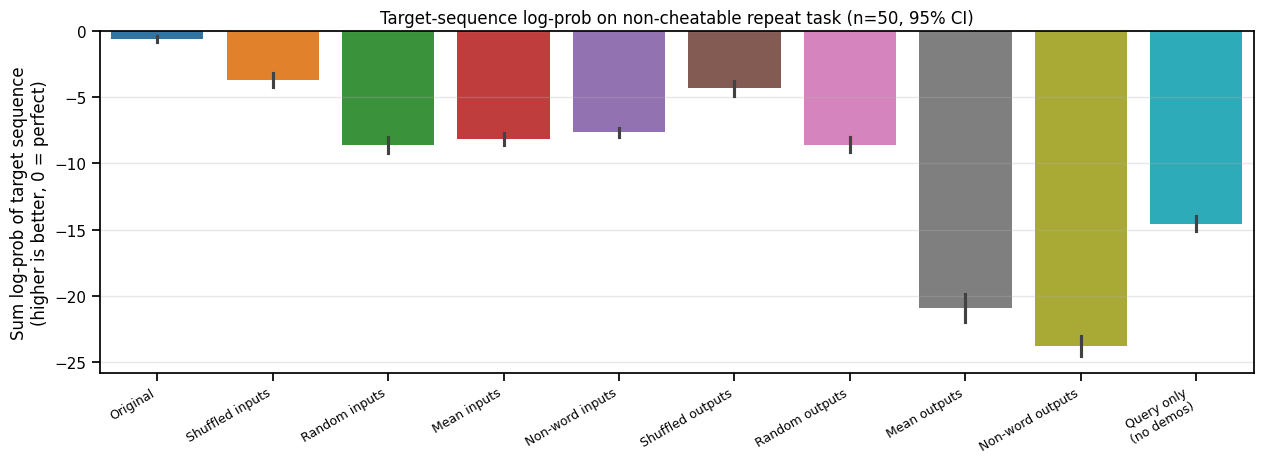

In [9]:
print(f'{"Condition":<24} {"Mean logp":>10}  {"[95% CI]":>22}')
print('-' * 60)
for c in CONDS:
    vals = logp[c]
    mean = vals.mean()
    se = vals.std(ddof=1) / np.sqrt(len(vals))
    lo, hi = mean - 1.96 * se, mean + 1.96 * se
    print(f'{c:<24} {mean:>10.3f}  [{lo:>8.3f}, {hi:>8.3f}]')

df_long_logp = pd.DataFrame({
    'Condition': np.concatenate([[tick_map[c]] * total_n for c in order_keys]),
    'LogProb':   np.concatenate([logp[c] for c in order_keys]),
})

fig, ax = plt.subplots(figsize=(6.4*2, 4.8))
sns.barplot(data=df_long_logp, x='Condition', y='LogProb', order=order_labels,
            palette='tab10', errorbar=('ci', 95), linewidth=0, ax=ax)
ax.set_ylabel('Sum log-prob of target sequence\n(higher is better, 0 = perfect)')
ax.set_xlabel('')
ax.set_title(f'Target-sequence log-prob on non-cheatable {RULE_NAME} task (n={total_n}, 95% CI)')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

# Output-to-input attention head ablation

Identify heads whose attention concentrates from demo output positions back to demo input positions within the same demo. These are the candidate "input-output routing" heads that build the relationship signal between inputs and outputs. Ablate them and measure ICL accuracy drop on the repetition task.

**Scoring:** for each head, compute the average attention weight from output positions to within-demo input positions, averaged across prompts. Select heads in the top 10% by this score. Ablate them (zero their output) during ICL forward passes.

**Prediction:** if these heads route input content to outputs (a key step in rule inference), ablating them should break the repetition task. Accuracy should drop substantially.

In [10]:
# Score: avg attention from output queries to within-demo input keys, MINUS avg attention from
# any non-output query position to any input key (causal mask q >= k). Heads that selectively
# route output→input score high; heads that broadly attend to inputs from any query position
# score near zero. Vectorized via mask tensors.
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads

oi_num_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
oi_baseline_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
oi_score_cnt = 0
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

for pdata in tqdm(prompts_data):
    demos = pdata['demo_pairs']
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    seq_len = tokens.shape[1]
    per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
    
    all_input_positions = set()
    all_output_positions = set()
    for d in per_demo:
        for p in d.get('input_positions', []):  all_input_positions.add(p)
        for p in d.get('output_positions', []): all_output_positions.add(p)
    
    # Numerator mask: (output query, within-demo input key)
    num_mask = torch.zeros(seq_len, seq_len)
    for d in per_demo:
        ins  = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        for op in outs:
            for ip in ins:
                num_mask[op, ip] = 1.0
    
    # Baseline mask: (any non-output query, any input key) with causal mask
    base_mask = torch.zeros(seq_len, seq_len)
    all_inputs_list = sorted(all_input_positions)
    for q in range(seq_len):
        if q in all_output_positions: continue
        for ik in all_inputs_list:
            if ik <= q:
                base_mask[q, ik] = 1.0
    
    n_num_pairs  = int(num_mask.sum().item())
    n_base_pairs = int(base_mask.sum().item())
    if n_num_pairs == 0 or n_base_pairs == 0: continue
    
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
    
    for L in range(n_layers):
        patt = cache['pattern', L][0].cpu().float()  # [n_heads, seq, seq]
        num_per_head  = (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num_pairs
        base_per_head = (patt * base_mask).sum(dim=(1, 2)).numpy() / n_base_pairs
        oi_num_sum[L, :]      += num_per_head
        oi_baseline_sum[L, :] += base_per_head
    
    oi_score_cnt += 1
    del cache
    torch.cuda.empty_cache()

oi_num      = oi_num_sum      / max(oi_score_cnt, 1)
oi_baseline = oi_baseline_sum / max(oi_score_cnt, 1)
oi_score    = oi_num - oi_baseline

# Flatten and rank
flat = [(L, h, oi_score[L, h]) for L in range(n_layers) for h in range(n_heads)]
flat.sort(key=lambda x: -x[2])
top10pct = int(0.10 * len(flat))
top_heads = [(L, h) for L, h, s in flat[:top10pct]]
print(f'Scored {oi_score_cnt} prompts')
print(f'Top 10 heads by selective output→input score:')
for L, h, s in flat[:10]:
    print(f'  L{L:2d}H{h:2d}: score={s:+.4f}  (output→input={oi_num[L,h]:.4f}, non-output→input baseline={oi_baseline[L,h]:.4f})')
print(f'\nAblating top {top10pct} heads ({100*top10pct/(n_layers*n_heads):.1f}% of all heads)')

100%|██████████| 50/50 [00:06<00:00,  7.27it/s]

Scored 50 prompts
Top 10 heads by selective output→input score:
  L 4H14: score=+0.2653  (output→input=0.2704, non-output→input baseline=0.0051)
  L 8H 8: score=+0.2384  (output→input=0.2424, non-output→input baseline=0.0040)
  L13H14: score=+0.1998  (output→input=0.2042, non-output→input baseline=0.0045)
  L14H22: score=+0.1582  (output→input=0.1723, non-output→input baseline=0.0142)
  L18H11: score=+0.1420  (output→input=0.1637, non-output→input baseline=0.0217)
  L16H 3: score=+0.1348  (output→input=0.1428, non-output→input baseline=0.0080)
  L 5H 8: score=+0.1233  (output→input=0.1276, non-output→input baseline=0.0043)
  L18H10: score=+0.1225  (output→input=0.1389, non-output→input baseline=0.0164)
  L23H10: score=+0.1221  (output→input=0.1410, non-output→input baseline=0.0189)
  L13H13: score=+0.1200  (output→input=0.1254, non-output→input baseline=0.0055)

Ablating top 67 heads (10.0% of all heads)


In [20]:
import pickle
with open('results/repetition_top10_heads.pkl', 'wb') as f:
    pickle.dump({'top10': top10_heads, 'rand10': rand10_heads,
                 'oi_score': oi_score, 'flat': flat}, f)

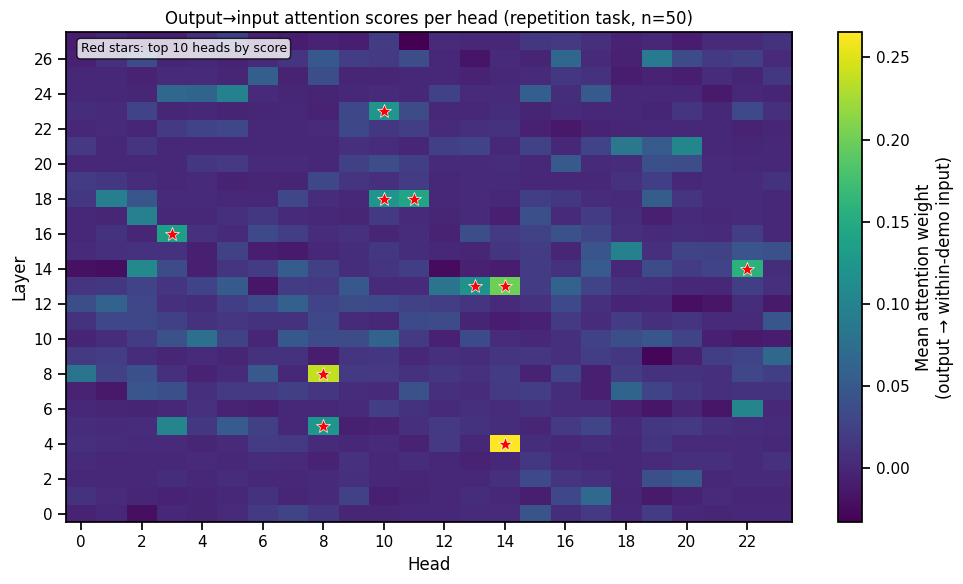

Top 10 heads by output→input score:
  L 4H14: 0.2653
  L 8H 8: 0.2384
  L13H14: 0.1998
  L14H22: 0.1582
  L18H11: 0.1420
  L16H 3: 0.1348
  L 5H 8: 0.1233
  L18H10: 0.1225
  L23H10: 0.1221
  L13H13: 0.1200


In [11]:
# Heatmap of output→within-demo-input attention scores per (layer, head)
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(oi_score, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(im, ax=ax, label='Mean attention weight\n(output → within-demo input)')
ax.set_xlabel('Head')
ax.set_ylabel('Layer')
ax.set_title('Output→input attention scores per head (repetition task, n=50)')
ax.set_xticks(range(0, n_heads, max(1, n_heads // 12)))
ax.set_yticks(range(0, n_layers, max(1, n_layers // 14)))
ax.grid(False)

# Annotate the top 10 heads
for L, h, s in flat[:10]:
    ax.plot(h, L, 'r*', markersize=10, markeredgecolor='white', markeredgewidth=0.5)

# Add a note about the annotation
ax.text(0.02, 0.98, 'Red stars: top 10 heads by score', transform=ax.transAxes,
        verticalalignment='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout(); plt.show()

# Print top 10 for reference
print('Top 10 heads by output→input score:')
for L, h, s in flat[:10]:
    print(f'  L{L:2d}H{h:2d}: {s:.4f}')

Aggregating attention: 100%|██████████| 50/50 [00:06<00:00,  7.38it/s]


Aggregated attention patterns for top 9 heads across 50 prompts


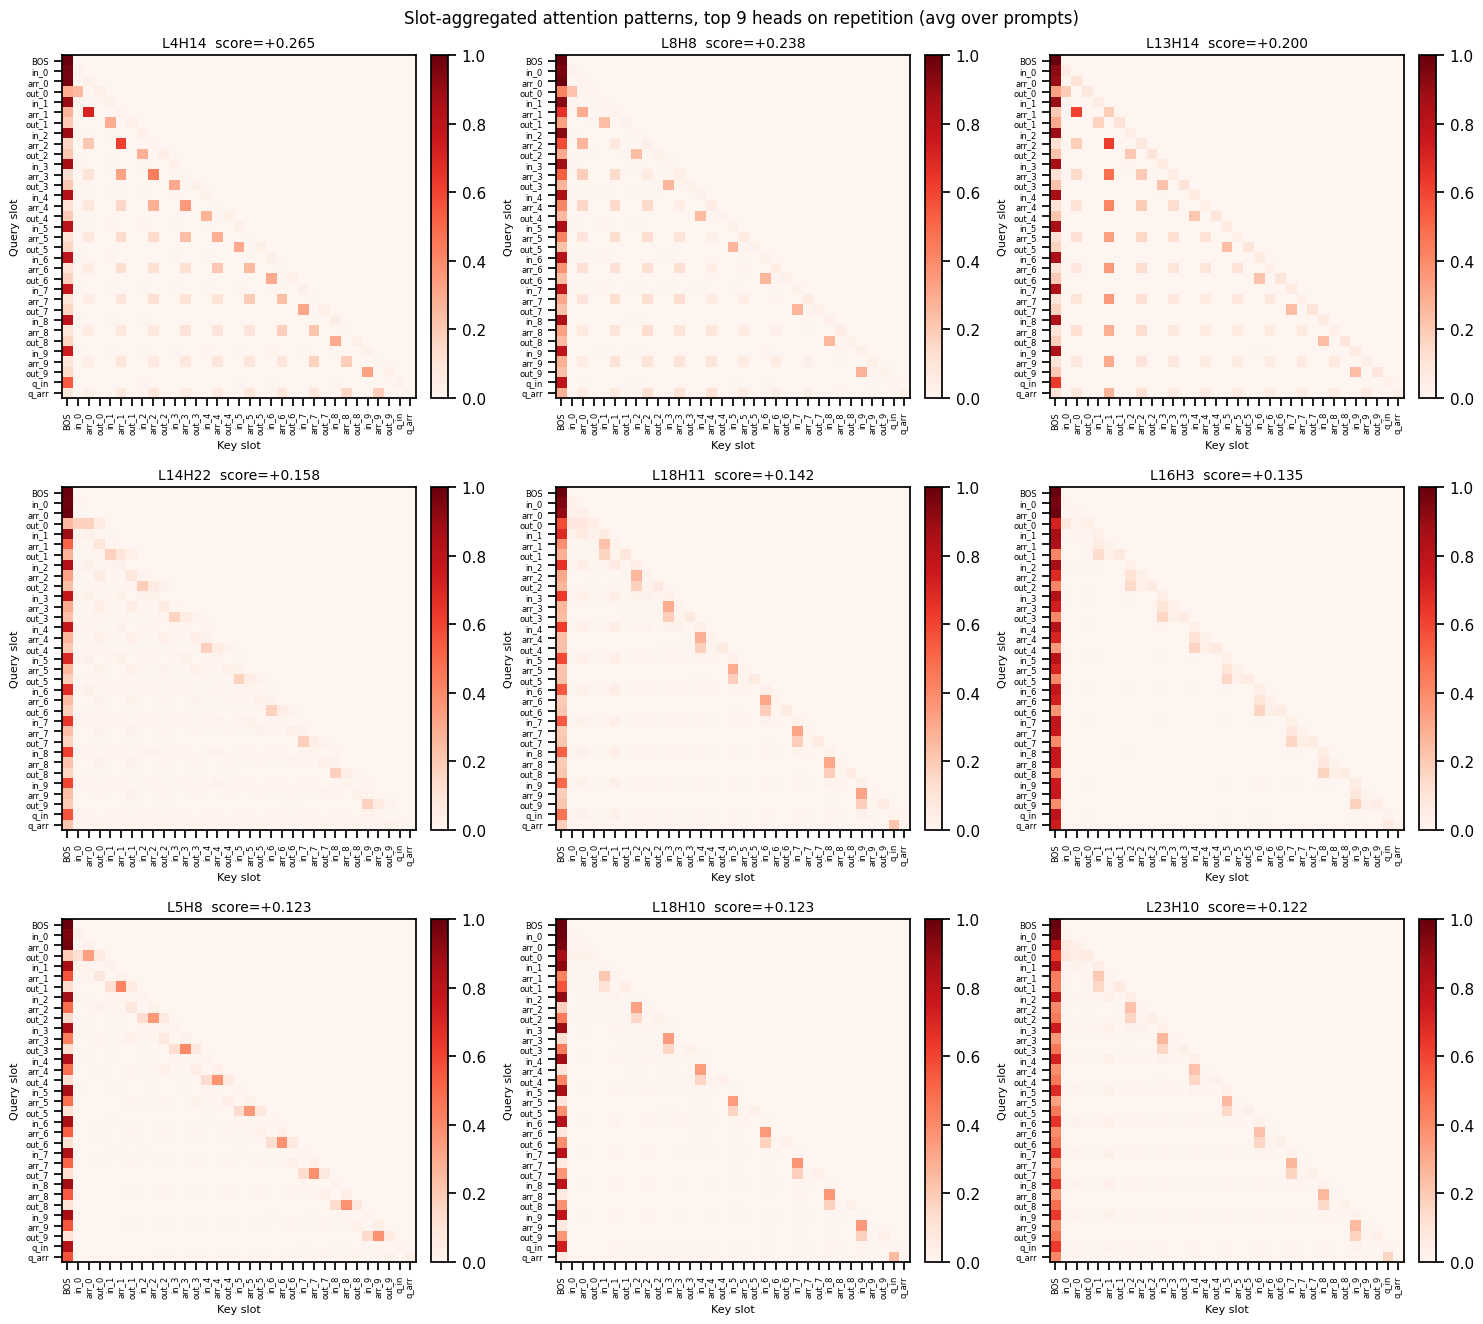

In [12]:
# Slot-aggregated average attention pattern for top output→input heads.
# Slots: BOS + 10 × (in_d, arr_d, out_d) + q_in + q_arr = 32 slots.
# For each top head, average the slot-binned attention pattern across all prompts.

n_demos_assumed = 10
slot_labels = ['BOS']
for d in range(n_demos_assumed):
    slot_labels += [f'in_{d}', f'arr_{d}', f'out_{d}']
slot_labels += ['q_in', 'q_arr']
n_slots = len(slot_labels)
slot_idx = {s: i for i, s in enumerate(slot_labels)}

def position_to_slot(pos, per_demo, seq_len):
    if pos == 0: return 'BOS'
    for d_idx, d in enumerate(per_demo):
        ins  = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        if pos in ins:  return f'in_{d_idx}'
        if pos in outs: return f'out_{d_idx}'
        if ins and outs and (max(ins) < pos < min(outs)): return f'arr_{d_idx}'
    last_demo = per_demo[-1]
    last_out = max(last_demo.get('output_positions', [0]))
    if pos > last_out:
        if pos == seq_len - 1: return 'q_arr'
        return 'q_in'
    return None

TOP_N_TO_PLOT = 9
heads_to_plot = [(L, h) for L, h, s in flat[:TOP_N_TO_PLOT]]

agg_sum = {(L, h): np.zeros((n_slots, n_slots), dtype=np.float64) for L, h in heads_to_plot}
agg_cnt = {(L, h): np.zeros((n_slots, n_slots), dtype=np.int64) for L, h in heads_to_plot}

for pdata in tqdm(prompts_data, desc='Aggregating attention'):
    demos = pdata['demo_pairs']
    if len(demos) != n_demos_assumed: continue
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    seq_len = tokens.shape[1]
    per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
    
    pos_slot_arr = np.full(seq_len, -1, dtype=np.int64)
    for pos in range(seq_len):
        s = position_to_slot(pos, per_demo, seq_len)
        if s is not None:
            pos_slot_arr[pos] = slot_idx[s]
    
    valid = pos_slot_arr >= 0
    if not valid.any(): continue
    
    q_idx, k_idx = np.meshgrid(np.arange(seq_len), np.arange(seq_len), indexing='ij')
    causal_mask = (q_idx >= k_idx) & valid[q_idx] & valid[k_idx]
    q_slot_grid = np.where(causal_mask, pos_slot_arr[q_idx], -1)
    k_slot_grid = np.where(causal_mask, pos_slot_arr[k_idx], -1)
    flat_slot_idx = q_slot_grid * n_slots + k_slot_grid
    flat_valid = causal_mask
    
    counts_flat = np.bincount(flat_slot_idx[flat_valid], minlength=n_slots * n_slots)
    slot_cnt = counts_flat.reshape(n_slots, n_slots)
    
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
    
    for L, h in heads_to_plot:
        patt = cache['pattern', L][0, h].cpu().float().numpy()
        sums_flat = np.bincount(
            flat_slot_idx[flat_valid],
            weights=patt[flat_valid],
            minlength=n_slots * n_slots,
        )
        slot_sum = sums_flat.reshape(n_slots, n_slots)
        with np.errstate(invalid='ignore', divide='ignore'):
            slot_avg = np.where(slot_cnt > 0, slot_sum / slot_cnt, 0.0)
        agg_sum[(L, h)] += slot_avg
        agg_cnt[(L, h)] += (slot_cnt > 0).astype(np.int64)
    
    del cache
    torch.cuda.empty_cache()

head_patterns = {}
for L, h in heads_to_plot:
    with np.errstate(invalid='ignore', divide='ignore'):
        head_patterns[(L, h)] = np.where(agg_cnt[(L, h)] > 0, agg_sum[(L, h)] / agg_cnt[(L, h)], 0.0)

print(f'Aggregated attention patterns for top {TOP_N_TO_PLOT} heads across {len(prompts_data)} prompts')

n_cols_p = 3
n_rows_p = int(np.ceil(len(heads_to_plot) / n_cols_p))
fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(5*n_cols_p, 4.5*n_rows_p))
axes = axes.flatten()

for ax, (L, h) in zip(axes, heads_to_plot):
    pat = head_patterns[(L, h)]
    im = ax.imshow(pat, aspect='auto', cmap='Reds', origin='upper', vmin=0)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'L{L}H{h}  score={oi_score[L,h]:+.3f}', fontsize=10)
    ax.set_xticks(range(n_slots))
    ax.set_xticklabels(slot_labels, rotation=90, fontsize=6)
    ax.set_yticks(range(n_slots))
    ax.set_yticklabels(slot_labels, fontsize=6)
    ax.set_xlabel('Key slot', fontsize=8)
    ax.set_ylabel('Query slot', fontsize=8)

for ax in axes[len(heads_to_plot):]:
    ax.set_visible(False)

fig.suptitle(f'Slot-aggregated attention patterns, top {TOP_N_TO_PLOT} heads on repetition (avg over prompts)', fontsize=12)
plt.tight_layout(); plt.show()

In [13]:
# Build head sets for four ablation conditions:
#   1. Top 1% by output→input score
#   2. Top 10% by output→input score
#   3. Random 1% of heads (control for top-1%)
#   4. Random 10% of heads (control for top-10%)
import random as _random

from collections import defaultdict

def make_ablation_hooks(heads_by_layer):
    fwd_hooks = []
    for L, h_list in heads_by_layer.items():
        def hook(z, hook, _h_list=h_list):
            for h in _h_list:
                z[0, :, h, :] = 0
            return z
        fwd_hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return fwd_hooks

def heads_by_layer_from(head_list):
    d = defaultdict(list)
    for L, h in head_list:
        d[L].append(h)
    return d

total_heads = len(flat)
top1pct_n  = max(1, int(0.01 * total_heads))
top10pct_n = max(1, int(0.10 * total_heads))

top1_heads  = [(L, h) for L, h, s in flat[:top1pct_n]]
top10_heads = [(L, h) for L, h, s in flat[:top10pct_n]]

# Random heads: sample from all (layer, head) pairs, excluding overlap with top sets
# to keep comparison clean (random heads are not among the top heads)
all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]
_rng = _random.Random(0)

# For random-1%: sample top1pct_n heads not among top1_heads
top1_set = set(top1_heads)
available_for_rand1 = [p for p in all_pairs if p not in top1_set]
rand1_heads = _rng.sample(available_for_rand1, top1pct_n)

# For random-10%: sample top10pct_n heads not among top10_heads
top10_set = set(top10_heads)
available_for_rand10 = [p for p in all_pairs if p not in top10_set]
rand10_heads = _rng.sample(available_for_rand10, top10pct_n)

print(f'Ablation conditions:')
print(f'  Top 1% (by o→i score): {top1pct_n} heads')
print(f'  Top 10% (by o→i score): {top10pct_n} heads')
print(f'  Random 1%: {top1pct_n} heads (disjoint from top 1%)')
print(f'  Random 10%: {top10pct_n} heads (disjoint from top 10%)')

head_sets = {
    'top1':  top1_heads,
    'top10': top10_heads,
    'rand1': rand1_heads,
    'rand10': rand10_heads,
}

def heads_by_layer_from(head_list):
    d = defaultdict(list)
    for L, h in head_list:
        d[L].append(h)
    return d

correct_abl = {name: [] for name in head_sets}

for pdata in tqdm(prompts_data):
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    for name, hs in head_sets.items():
        hooks = make_ablation_hooks(heads_by_layer_from(hs))
        correct_abl[name].append(check_correct_with_hooks(model, tokens, pdata['query_output'], hooks=hooks))
    torch.cuda.empty_cache()

for name in head_sets:
    correct_abl[name] = np.array(correct_abl[name])

print(f'\nAccuracy comparison:')
print(f'  Orig:                   {correct["orig"].mean():.3f}')
print(f'  Top 1% o→i ablated:    {correct_abl["top1"].mean():.3f}')
print(f'  Top 10% o→i ablated:   {correct_abl["top10"].mean():.3f}')
print(f'  Random 1% ablated:     {correct_abl["rand1"].mean():.3f}')
print(f'  Random 10% ablated:    {correct_abl["rand10"].mean():.3f}')
print(f'  Shuffled inputs:       {correct["shuffled_inputs"].mean():.3f}')
print(f'  Shuffled outputs:      {correct["shuffled_outputs"].mean():.3f}')
print(f'  Query only:            {correct["query_only"].mean():.3f}')

Ablation conditions:
  Top 1% (by o→i score): 6 heads
  Top 10% (by o→i score): 67 heads
  Random 1%: 6 heads (disjoint from top 1%)
  Random 10%: 67 heads (disjoint from top 10%)


100%|██████████| 50/50 [01:26<00:00,  1.73s/it]


Accuracy comparison:
  Orig:                   0.960
  Top 1% o→i ablated:    0.560
  Top 10% o→i ablated:   0.000
  Random 1% ablated:     0.960
  Random 10% ablated:    0.900
  Shuffled inputs:       0.480
  Shuffled outputs:      0.380
  Query only:            0.000


/tmp/ipykernel_2452407/3307447862.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cmp, x='Condition', y='Correct', order=labels_cmp,


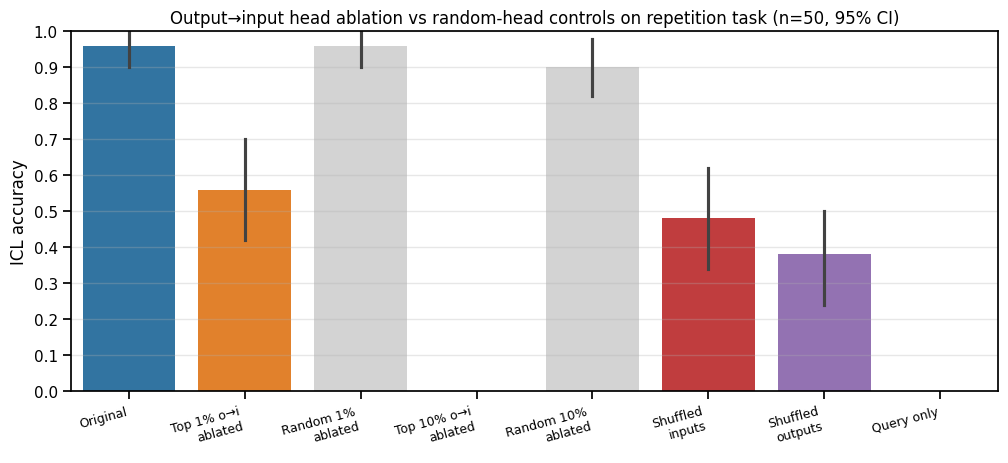

In [14]:
labels_cmp = [
    'Original',
    'Top 1% o→i\nablated',
    'Random 1%\nablated',
    'Top 10% o→i\nablated',
    'Random 10%\nablated',
    'Shuffled\ninputs',
    'Shuffled\noutputs',
    'Query only',
]
values_cmp = [
    correct['orig'],
    correct_abl['top1'],
    correct_abl['rand1'],
    correct_abl['top10'],
    correct_abl['rand10'],
    correct['shuffled_inputs'],
    correct['shuffled_outputs'],
    correct['query_only'],
]
df_cmp = pd.DataFrame({
    'Condition': np.concatenate([[lab] * len(v) for lab, v in zip(labels_cmp, values_cmp)]),
    'Correct':   np.concatenate(values_cmp),
})

# Color top-N blue, random-N gray to make the comparison visible
palette = {
    'Original':             sns.color_palette('tab10')[0],
    'Top 1% o→i\nablated':  sns.color_palette('tab10')[1],
    'Random 1%\nablated':   'lightgray',
    'Top 10% o→i\nablated': sns.color_palette('tab10')[1],
    'Random 10%\nablated':  'lightgray',
    'Shuffled\ninputs':     sns.color_palette('tab10')[3],
    'Shuffled\noutputs':    sns.color_palette('tab10')[4],
    'Query only':           sns.color_palette('tab10')[7],
}

fig, ax = plt.subplots(figsize=(6.4*1.6, 4.8))
sns.barplot(data=df_cmp, x='Condition', y='Correct', order=labels_cmp,
            palette=palette, errorbar=('ci', 95), linewidth=0, ax=ax)
ax.set_ylabel('ICL accuracy')
ax.set_xlabel('')
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.1))
n_show = len(correct_abl['top1'])
ax.set_title(f'Output→input head ablation vs random-head controls on repetition task (n={n_show}, 95% CI)')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

In [15]:
# Alternate scoring: attention from the LAST output token only, back to within-demo input positions.
# Average across demos (one last-output-token per demo) and across prompts.
oi_score_last_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
oi_score_last_cnt = 0

for pdata in tqdm(prompts_data):
    demos = pdata['demo_pairs']
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
    
    # Build (last-output pos, input pos) pairs per demo
    oi_pairs_last = []
    for d in per_demo:
        ins  = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        if not ins or not outs: continue
        last_op = max(outs)  # the final output token of this demo
        for ip in ins:
            oi_pairs_last.append((last_op, ip))
    if not oi_pairs_last: continue
    
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
    
    for L in range(n_layers):
        patt = cache['pattern', L][0]
        for h in range(n_heads):
            s = 0.0
            for op, ip in oi_pairs_last:
                s += patt[h, op, ip].item()
            oi_score_last_sum[L, h] += s / len(oi_pairs_last)
    
    oi_score_last_cnt += 1
    del cache
    torch.cuda.empty_cache()

oi_score_last = oi_score_last_sum / max(oi_score_last_cnt, 1)

flat_last = [(L, h, oi_score_last[L, h]) for L in range(n_layers) for h in range(n_heads)]
flat_last.sort(key=lambda x: -x[2])
print(f'Top 10 heads by LAST-output→input score:')
for L, h, s in flat_last[:10]:
    print(f'  L{L}H{h}: {s:.4f}')

100%|██████████| 50/50 [00:18<00:00,  2.74it/s]

Top 10 heads by LAST-output→input score:
  L8H8: 0.2707
  L13H14: 0.2311
  L4H14: 0.2231
  L26H19: 0.1310
  L25H6: 0.0971
  L1H17: 0.0870
  L6H22: 0.0799
  L13H13: 0.0729
  L13H9: 0.0723
  L25H8: 0.0718


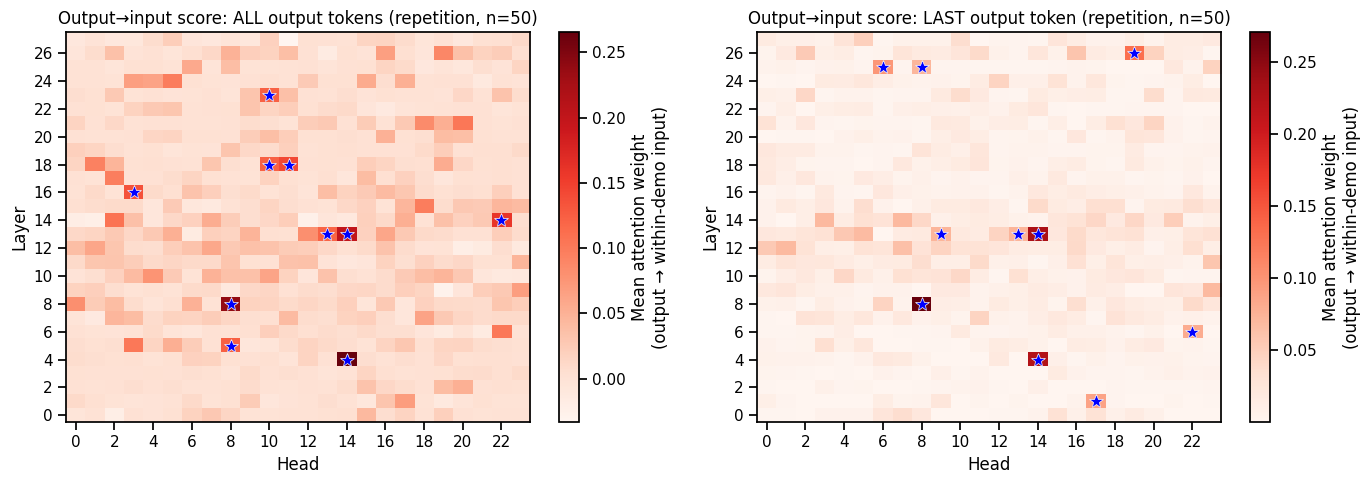

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in [(axes[0], oi_score, 'ALL output tokens'),
                         (axes[1], oi_score_last, 'LAST output token')]:
    im = ax.imshow(data, aspect='auto', cmap='Reds', origin='lower')
    plt.colorbar(im, ax=ax, label='Mean attention weight\n(output → within-demo input)')
    ax.set_xlabel('Head')
    ax.set_ylabel('Layer')
    ax.set_title(f'Output→input score: {title} (repetition, n={len(prompts_data)})')
    ax.set_xticks(range(0, n_heads, max(1, n_heads // 12)))
    ax.set_yticks(range(0, n_layers, max(1, n_layers // 14)))
    ax.grid(False)
    
    # Annotate top 10 for each
    top10 = flat[:10] if title == 'ALL output tokens' else flat_last[:10]
    for L, h, s in top10:
        ax.plot(h, L, 'b*', markersize=10, markeredgecolor='white', markeredgewidth=0.5)

plt.tight_layout(); plt.show()

100%|██████████| 50/50 [01:20<00:00,  1.62s/it]
/tmp/ipykernel_2452407/785868662.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cmp, x='Condition', y='Correct', order=labels_cmp,



Accuracy comparison (last-output score):
  Orig:                         0.960
  Top 1% o→i (last) ablated:    0.840
  Top 10% o→i (last) ablated:   0.500
  Random 1% ablated:            0.940
  Random 10% ablated:           0.900
  Shuffled inputs:              0.480
  Shuffled outputs:             0.380
  Query only:                   0.000


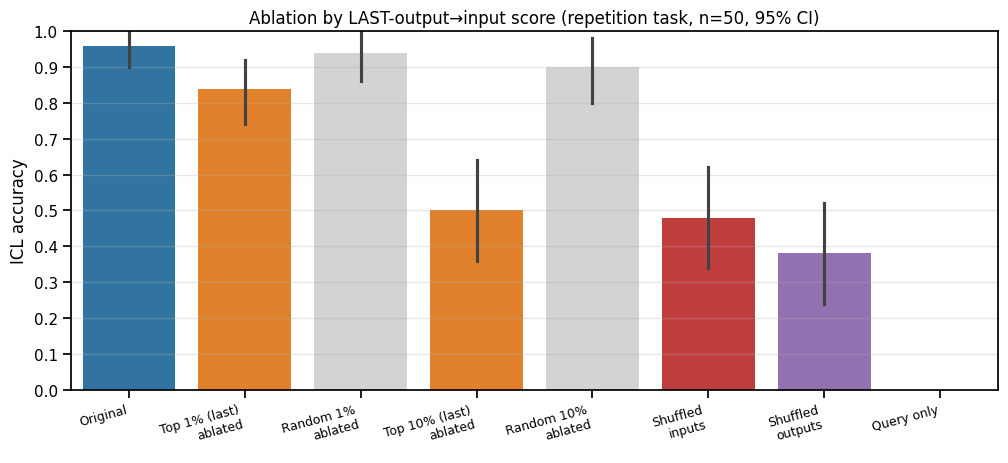

In [17]:
# Ablate top 1% and top 10% by LAST-output score, with matched random controls
import random as _random

total_heads = len(flat_last)
top1pct_n  = max(1, int(0.01 * total_heads))
top10pct_n = max(1, int(0.10 * total_heads))

top1_heads_last  = [(L, h) for L, h, s in flat_last[:top1pct_n]]
top10_heads_last = [(L, h) for L, h, s in flat_last[:top10pct_n]]

all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]
_rng = _random.Random(0)

top1_set_last  = set(top1_heads_last)
top10_set_last = set(top10_heads_last)
rand1_heads_last  = _rng.sample([p for p in all_pairs if p not in top1_set_last],  top1pct_n)
rand10_heads_last = _rng.sample([p for p in all_pairs if p not in top10_set_last], top10pct_n)

head_sets_last = {
    'top1_last':  top1_heads_last,
    'top10_last': top10_heads_last,
    'rand1_last':  rand1_heads_last,
    'rand10_last': rand10_heads_last,
}

correct_abl_last = {name: [] for name in head_sets_last}

for pdata in tqdm(prompts_data):
    tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
    for name, hs in head_sets_last.items():
        hooks = make_ablation_hooks(heads_by_layer_from(hs))
        correct_abl_last[name].append(check_correct_with_hooks(model, tokens, pdata['query_output'], hooks=hooks))
    torch.cuda.empty_cache()

for name in head_sets_last:
    correct_abl_last[name] = np.array(correct_abl_last[name])

print(f'\nAccuracy comparison (last-output score):')
print(f'  Orig:                         {correct["orig"].mean():.3f}')
print(f'  Top 1% o→i (last) ablated:    {correct_abl_last["top1_last"].mean():.3f}')
print(f'  Top 10% o→i (last) ablated:   {correct_abl_last["top10_last"].mean():.3f}')
print(f'  Random 1% ablated:            {correct_abl_last["rand1_last"].mean():.3f}')
print(f'  Random 10% ablated:           {correct_abl_last["rand10_last"].mean():.3f}')
print(f'  Shuffled inputs:              {correct["shuffled_inputs"].mean():.3f}')
print(f'  Shuffled outputs:             {correct["shuffled_outputs"].mean():.3f}')
print(f'  Query only:                   {correct["query_only"].mean():.3f}')

labels_cmp = [
    'Original',
    'Top 1% (last)\nablated',
    'Random 1%\nablated',
    'Top 10% (last)\nablated',
    'Random 10%\nablated',
    'Shuffled\ninputs',
    'Shuffled\noutputs',
    'Query only',
]
values_cmp = [
    correct['orig'],
    correct_abl_last['top1_last'],
    correct_abl_last['rand1_last'],
    correct_abl_last['top10_last'],
    correct_abl_last['rand10_last'],
    correct['shuffled_inputs'],
    correct['shuffled_outputs'],
    correct['query_only'],
]
df_cmp = pd.DataFrame({
    'Condition': np.concatenate([[lab] * len(v) for lab, v in zip(labels_cmp, values_cmp)]),
    'Correct':   np.concatenate(values_cmp),
})

palette = {
    'Original':                 sns.color_palette('tab10')[0],
    'Top 1% (last)\nablated':   sns.color_palette('tab10')[1],
    'Random 1%\nablated':       'lightgray',
    'Top 10% (last)\nablated':  sns.color_palette('tab10')[1],
    'Random 10%\nablated':      'lightgray',
    'Shuffled\ninputs':         sns.color_palette('tab10')[3],
    'Shuffled\noutputs':        sns.color_palette('tab10')[4],
    'Query only':               sns.color_palette('tab10')[7],
}

fig, ax = plt.subplots(figsize=(6.4*1.6, 4.8))
sns.barplot(data=df_cmp, x='Condition', y='Correct', order=labels_cmp,
            palette=palette, errorbar=('ci', 95), linewidth=0, ax=ax)
ax.set_ylabel('ICL accuracy')
ax.set_xlabel('')
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.1, 0.1))
n_show = len(correct_abl_last['top1_last'])
ax.set_title(f'Ablation by LAST-output→input score (repetition task, n={n_show}, 95% CI)')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
plt.tight_layout(); plt.show()

# TV recovery in 0-shot context

For each manipulation condition, extract the residual stream at the query-arrow position from the manipulated ICL prompt, patch it into a zero-shot `query_input →` prompt at each layer, and check whether the model produces the correct repeated output via greedy decode.

**Two separate analyses below:** one for input-manipulation conditions, one for output-manipulation conditions. Each produces a per-layer line plot analogous to the Hendel claim-2b plot.

**Whitespace normalization note.** The patched model often outputs `X\nX` instead of `XX` because the TV carries demo-format context (each demo in the prompt ends with `\n` before the next). The check normalizes by removing all whitespace from both target and generated text so `majul\nmajul` matches `majulmajul`.

## Shared helpers

In [18]:
def get_query_arrow_position(model, prompt):
    arrow_tok = model.to_tokens(' \u2192', prepend_bos=False)[0, 0].item()
    tokens = model.to_tokens(prompt, prepend_bos=True)[0]
    arrow_positions = (tokens == arrow_tok).nonzero().squeeze(-1).tolist()
    if not arrow_positions: return None
    return arrow_positions[-1]

@torch.no_grad()
def extract_full_resid(model, tokens, arrow_pos, hooks=None):
    if hooks:
        with model.hooks(fwd_hooks=hooks):
            _, cache = model.run_with_cache(tokens, names_filter=lambda n: 'resid_post' in n)
    else:
        _, cache = model.run_with_cache(tokens, names_filter=lambda n: 'resid_post' in n)
    nL = model.cfg.n_layers
    return torch.stack([cache['resid_post', L][0, arrow_pos].cpu().float() for L in range(nL)])

@torch.no_grad()
def patched_multitoken_check(model, zs_prompt, tv_vec, layer, expected, max_new_tokens=6):
    """Patched greedy decode with early-exit. Normalizes all whitespace before comparison."""
    tokens = model.to_tokens(zs_prompt, prepend_bos=True)
    device = next(model.parameters()).device
    tv_t = torch.tensor(tv_vec, device=device, dtype=model.cfg.dtype)
    orig_len = tokens.shape[1]
    
    def _normalize(s):
        return ''.join(s.split()).lower()
    
    target = _normalize(expected)
    generated = []
    cur_tokens = tokens.clone()
    for step in range(max_new_tokens):
        if cur_tokens.shape[1] == orig_len:
            def hook(value, hook, _tv=tv_t):
                value[0, -1, :] = _tv
                return value
            logits = model.run_with_hooks(cur_tokens,
                fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook)])[0, -1]
        else:
            logits = model(cur_tokens)[0, -1]
        nt = logits.argmax().item()
        generated.append(nt)
        cur_tokens = torch.cat([cur_tokens, torch.tensor([[nt]], device=cur_tokens.device)], dim=1)
        
        decoded_so_far = _normalize(model.tokenizer.decode(generated))
        if decoded_so_far and not target.startswith(decoded_so_far):
            return 0
        if decoded_so_far.startswith(target):
            return 1
    
    decoded = _normalize(model.tokenizer.decode(generated))
    return int(decoded.startswith(target))

@torch.no_grad()
def patched_target_logprob(model, zs_prompt, tv_vec, layer, expected):
    """Teacher-forced log-probability of the full target sequence under the patched model.
    The TV is patched only at the first forward step; subsequent steps use clean model with
    the ground-truth preceding target tokens. Returns sum_i log p(target_i | preceding target_<i)."""
    tokens = model.to_tokens(zs_prompt, prepend_bos=True)
    device = next(model.parameters()).device
    tv_t = torch.tensor(tv_vec, device=device, dtype=model.cfg.dtype)
    
    target_ids = model.to_tokens(' ' + expected.strip(), prepend_bos=False)[0].tolist()
    
    total_logprob = 0.0
    cur_tokens = tokens.clone()
    orig_len = cur_tokens.shape[1]
    
    for target_tok in target_ids:
        if cur_tokens.shape[1] == orig_len:
            def hook(value, hook, _tv=tv_t):
                value[0, -1, :] = _tv
                return value
            logits = model.run_with_hooks(cur_tokens,
                fwd_hooks=[(f'blocks.{layer}.hook_resid_post', hook)])[0, -1]
        else:
            logits = model(cur_tokens)[0, -1]
        
        log_probs = torch.log_softmax(logits.float(), dim=-1)
        total_logprob += log_probs[target_tok].item()
        
        cur_tokens = torch.cat([cur_tokens, torch.tensor([[target_tok]], device=cur_tokens.device)], dim=1)
    
    return total_logprob

n_layers = model.cfg.n_layers
print(f'n_layers = {n_layers}')

n_layers = 28


## TV recovery: input-side manipulations

Conditions: orig, shuffled_inputs, random_inputs, mean_embed_inputs, star_inputs, query_only.

In [19]:
TV_CONDS_IN = ['orig', 'shuffled_inputs', 'random_inputs', 'mean_embed_inputs',
               'star_inputs', 'query_only']
tv_rec_in  = {c: {L: [] for L in range(n_layers)} for c in TV_CONDS_IN}
tv_logp_in = {c: {L: [] for L in range(n_layers)} for c in TV_CONDS_IN}

heldout_queries = []
for pdata in prompts_data:
    demos = pdata['demo_pairs']
    used_words = set()
    for i, o in demos:
        used_words.add(i)
        used_words.add(o)
    used_words.add(pdata['query_input'])
    used_words.add(pdata['query_output'])
    available = [w for w in pool if w not in used_words]
    heldout = rng.choice(available)
    heldout_queries.append(heldout)

print(f'Example: source query={prompts_data[0]["query_input"]}, held-out query={heldout_queries[0]}')
print(f'  source expected={prompts_data[0]["query_output"]}, held-out expected={heldout_queries[0] + heldout_queries[0]}')

# Flat progress: 1 step per (prompt, condition) pair. Plus a mean_embed step per prompt.
all_conds_ordered = ['orig', 'shuffled_inputs', 'random_inputs', 'star_inputs', 'query_only']
total_steps = len(prompts_data) * (len(all_conds_ordered) + 1)  # +1 for mean_embed_inputs

pbar = tqdm(total=total_steps, desc='TV recovery (input)')

for p_idx, pdata in enumerate(prompts_data):
    demos = pdata['demo_pairs']
    qi = pdata['query_input']
    
    inputs  = [i for i, _ in demos]
    outputs = [o for _, o in demos]
    inputs_shuffled = inputs.copy(); rng.shuffle(inputs_shuffled)
    inputs_random   = [rng.choice(input_pool_all) for _ in inputs]
    
    prompts = {
        'orig':            pdata['prompt'],
        'shuffled_inputs': build_icl_prompt(list(zip(inputs_shuffled, outputs)), qi),
        'random_inputs':   build_icl_prompt(list(zip(inputs_random, outputs)), qi),
        'star_inputs':     build_icl_prompt([('*', o) for o in outputs], qi),
        'query_only':      f'{qi} \u2192',
    }
    tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
    arrow_pos = {k: get_query_arrow_position(model, v) for k, v in prompts.items()}
    
    ho_q = heldout_queries[p_idx]
    ho_ans = ho_q + ho_q
    zs_prompt = f'{ho_q} \u2192'
    
    for k in all_conds_ordered:
        pbar.set_postfix_str(f'prompt {p_idx+1}/{len(prompts_data)} | cond={k}')
        tv_all = extract_full_resid(model, tokens[k], arrow_pos[k])
        for L in range(n_layers):
            tv_vec_np = tv_all[L].numpy()
            tv_rec_in[k][L].append(patched_multitoken_check(model, zs_prompt, tv_vec_np, L, ho_ans))
            tv_logp_in[k][L].append(patched_target_logprob(model, zs_prompt, tv_vec_np, L, ho_ans))
        pbar.update(1)
    
    pbar.set_postfix_str(f'prompt {p_idx+1}/{len(prompts_data)} | cond=mean_embed_inputs')
    per_demo_orig = find_per_demo_positions(model, prompts['orig'], demos)
    input_positions = [p for d in per_demo_orig for p in d.get('input_positions', [])]
    hook = [('hook_embed', make_embed_hook(input_positions, mean_input_embed))]
    tv_all = extract_full_resid(model, tokens['orig'], arrow_pos['orig'], hooks=hook)
    for L in range(n_layers):
        tv_vec_np = tv_all[L].numpy()
        tv_rec_in['mean_embed_inputs'][L].append(patched_multitoken_check(model, zs_prompt, tv_vec_np, L, ho_ans))
        tv_logp_in['mean_embed_inputs'][L].append(patched_target_logprob(model, zs_prompt, tv_vec_np, L, ho_ans))
    pbar.update(1)
    
    torch.cuda.empty_cache()

pbar.close()

for c in TV_CONDS_IN:
    for L in range(n_layers):
        tv_rec_in[c][L]  = np.array(tv_rec_in[c][L])
        tv_logp_in[c][L] = np.array(tv_logp_in[c][L])
n_in = len(tv_rec_in['orig'][0])
print(f'Total prompts scored: {n_in}')

Example: source query=majul, held-out query=vurim
  source expected=majulmajul, held-out expected=vurimvurim


TV recovery (input):   3%|▎         | 8/300 [01:40<1:01:52, 12.71s/it, prompt 2/50 | cond=random_inputs]    

KeyboardInterrupt: 

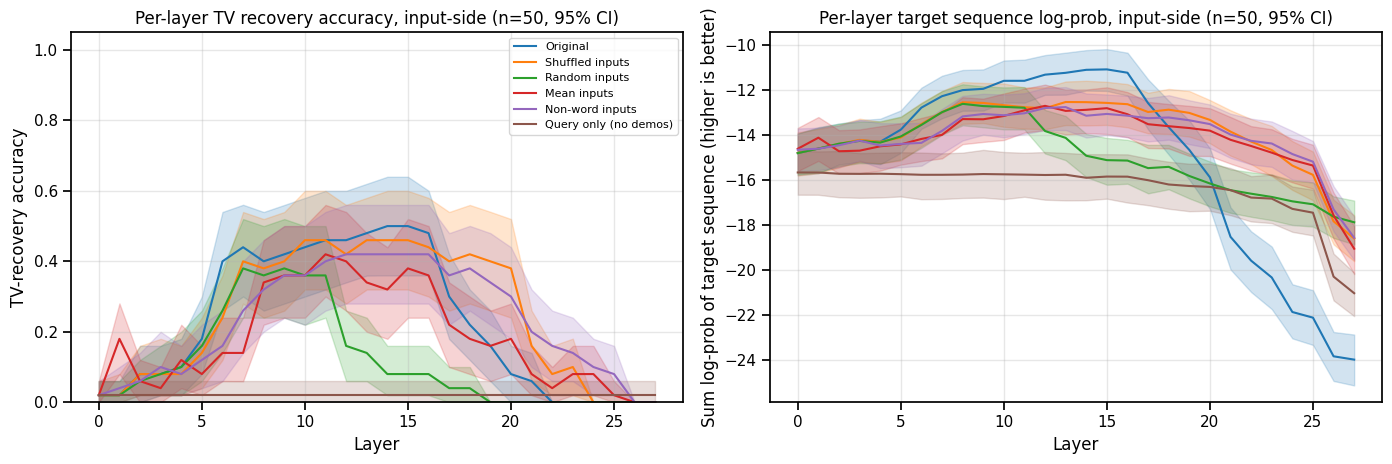

In [17]:
tick_map_in = {
    'orig':              'Original',
    'shuffled_inputs':   'Shuffled inputs',
    'random_inputs':     'Random inputs',
    'mean_embed_inputs': 'Mean inputs',
    'star_inputs':       'Non-word inputs',
    'query_only':        'Query only (no demos)',
}
label_order = [tick_map_in[c] for c in TV_CONDS_IN]

rows_acc = []
for c in TV_CONDS_IN:
    for L in range(n_layers):
        for v in tv_rec_in[c][L]:
            rows_acc.append({'Condition': tick_map_in[c], 'Layer': L, 'Recovery': v})
df_acc = pd.DataFrame(rows_acc)

rows_logp = []
for c in TV_CONDS_IN:
    for L in range(n_layers):
        for v in tv_logp_in[c][L]:
            rows_logp.append({'Condition': tick_map_in[c], 'Layer': L, 'LogProb': v})
df_logp = pd.DataFrame(rows_logp)

fig, axes = plt.subplots(1, 2, figsize=(6.4*2.2, 4.8))

sns.lineplot(data=df_acc, x='Layer', y='Recovery', hue='Condition', hue_order=label_order,
             palette='tab10', errorbar=('ci', 95), ax=axes[0])
axes[0].set_ylabel('TV-recovery accuracy')
axes[0].set_xlabel('Layer')
axes[0].set_ylim(0, 1.05)
axes[0].set_title(f'Per-layer TV recovery accuracy, input-side (n={n_in}, 95% CI)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='', loc='upper right', fontsize=8)

sns.lineplot(data=df_logp, x='Layer', y='LogProb', hue='Condition', hue_order=label_order,
             palette='tab10', errorbar=('ci', 95), ax=axes[1], legend=False)
axes[1].set_ylabel('Sum log-prob of target sequence (higher is better)')
axes[1].set_xlabel('Layer')
axes[1].set_title(f'Per-layer target sequence log-prob, input-side (n={n_in}, 95% CI)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## TV recovery: output-side manipulations

Conditions: orig, shuffled_outputs, random_outputs, mean_embed_outputs, star_outputs, query_only.

In [ ]:
TV_CONDS_OUT = ['orig', 'shuffled_outputs', 'random_outputs', 'mean_embed_outputs',
                'star_outputs', 'query_only']
tv_rec_out  = {c: {L: [] for L in range(n_layers)} for c in TV_CONDS_OUT}
tv_rank_out = {c: {L: [] for L in range(n_layers)} for c in TV_CONDS_OUT}

for pdata in tqdm(prompts_data):
    demos = pdata['demo_pairs']
    qi = pdata['query_input']
    ans = pdata['query_output']
    
    inputs  = [i for i, _ in demos]
    outputs = [o for _, o in demos]
    outputs_shuffled = outputs.copy(); rng.shuffle(outputs_shuffled)
    outputs_random   = [rng.choice(output_pool_all) for _ in outputs]
    
    prompts = {
        'orig':             pdata['prompt'],
        'shuffled_outputs': build_icl_prompt(list(zip(inputs, outputs_shuffled)), qi),
        'random_outputs':   build_icl_prompt(list(zip(inputs, outputs_random)), qi),
        'star_outputs':     build_icl_prompt([(i, '*') for i in inputs], qi),
        'query_only':       f'{qi} \u2192',
    }
    tokens = {k: model.to_tokens(v, prepend_bos=True) for k, v in prompts.items()}
    arrow_pos = {k: get_query_arrow_position(model, v) for k, v in prompts.items()}
    
    zs_prompt = f'{qi} \u2192'
    
    for k in ['orig', 'shuffled_outputs', 'random_outputs', 'star_outputs', 'query_only']:
        tv_all = extract_full_resid(model, tokens[k], arrow_pos[k])
        for L in range(n_layers):
            tv_rec_out[k][L].append(patched_multitoken_check(model, zs_prompt, tv_all[L].numpy(), L, ans))
    
    # mean_embed_outputs
    per_demo_orig = find_per_demo_positions(model, prompts['orig'], demos)
    output_positions = [p for d in per_demo_orig for p in d.get('output_positions', [])]
    hook = [('hook_embed', make_embed_hook(output_positions, mean_output_embed))]
    tv_all = extract_full_resid(model, tokens['orig'], arrow_pos['orig'], hooks=hook)
    for L in range(n_layers):
        tv_rec_out['mean_embed_outputs'][L].append(patched_multitoken_check(model, zs_prompt, tv_all[L].numpy(), L, ans))
    
    torch.cuda.empty_cache()

for c in TV_CONDS_OUT:
    for L in range(n_layers):
        tv_rec_out[c][L]  = np.array(tv_rec_out[c][L])
        tv_rank_out[c][L] = np.array(tv_rank_out[c][L])
n_out = len(tv_rec_out['orig'][0])
print(f'Total prompts scored: {n_out}')

In [ ]:
tick_map_out = {
    'orig':               'Original',
    'shuffled_outputs':   'Shuffled outputs',
    'random_outputs':     'Random outputs',
    'mean_embed_outputs': 'Mean outputs',
    'star_outputs':       'Non-word outputs',
    'query_only':         'Query only (no demos)',
}
label_order = [tick_map_out[c] for c in TV_CONDS_OUT]

rows_acc = []
for c in TV_CONDS_OUT:
    for L in range(n_layers):
        for v in tv_rec_out[c][L]:
            rows_acc.append({'Condition': tick_map_out[c], 'Layer': L, 'Recovery': v})
df_acc = pd.DataFrame(rows_acc)

rows_rank = []
for c in TV_CONDS_OUT:
    for L in range(n_layers):
        for v in tv_rank_out[c][L]:
            rows_rank.append({'Condition': tick_map_out[c], 'Layer': L, 'Rank': v})
df_rank = pd.DataFrame(rows_rank)

fig, axes = plt.subplots(1, 2, figsize=(6.4*2.2, 4.8))

sns.lineplot(data=df_acc, x='Layer', y='Recovery', hue='Condition', hue_order=label_order,
             palette='tab10', errorbar=('ci', 95), ax=axes[0])
axes[0].set_ylabel('TV-recovery accuracy')
axes[0].set_xlabel('Layer')
axes[0].set_ylim(0, 1.05)
axes[0].set_title(f'Per-layer TV recovery accuracy, output-side (n={n_out}, 95% CI)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(title='', loc='upper right', fontsize=8)

sns.lineplot(data=df_rank, x='Layer', y='Rank', hue='Condition', hue_order=label_order,
             palette='tab10', errorbar=('ci', 95), ax=axes[1], legend=False)
axes[1].set_ylabel('Rank of first target token (lower is better)')
axes[1].set_xlabel('Layer')
axes[1].set_yscale('symlog')
axes[1].set_ylim(bottom=0)
axes[1].set_title(f'Per-layer rank of first target token, output-side (n={n_out}, 95% CI)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
